In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'Notebook' else Path.cwd()
DB_PATH = PROJECT_ROOT / 'data' / 'clinical_trials.db'
conn = sqlite3.connect(DB_PATH)

print("Connected.")

Connected.


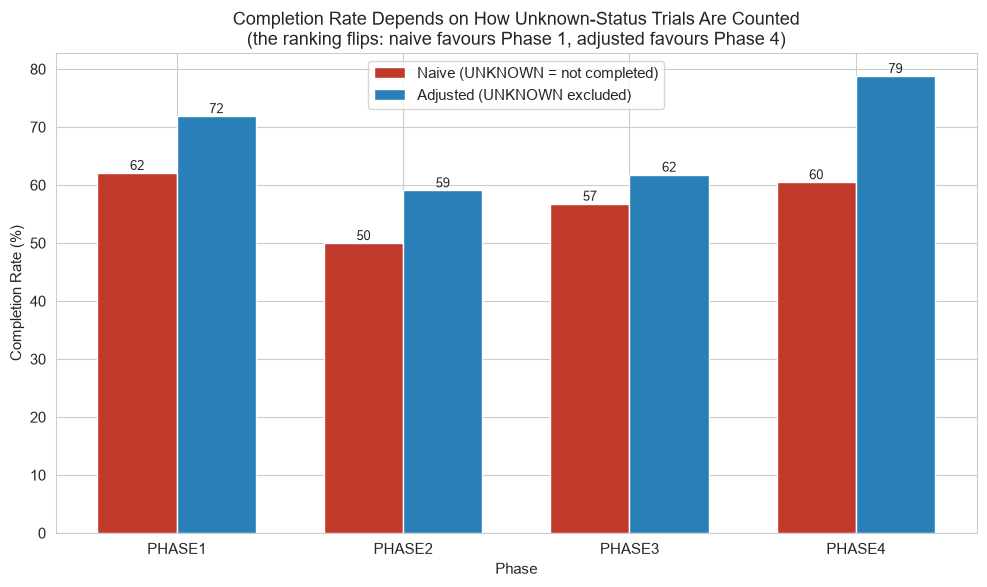

In [3]:
# Data: the completion rates you computed in Q3
query = """
WITH status_counts AS (
    SELECT phase,
           COUNT(*) AS total,
           SUM(CASE WHEN status = 'COMPLETED' THEN 1 ELSE 0 END) AS completed,
           SUM(CASE WHEN status = 'UNKNOWN' THEN 1 ELSE 0 END) AS unknown_status
    FROM studies
    WHERE study_type = 'INTERVENTIONAL' AND phase IS NOT NULL AND phase != 'NA'
    GROUP BY phase
)
SELECT phase,
       ROUND(100.0 * completed / total, 1) AS naive_rate,
       ROUND(100.0 * completed / NULLIF(total - unknown_status, 0), 1) AS adjusted_rate
FROM status_counts
WHERE phase != 'EARLY_PHASE1'   -- exclude n=3, too small
ORDER BY phase
"""
df = pd.read_sql(query, conn)

# Grouped bar chart
x = np.arange(len(df))
width = 0.35

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, df['naive_rate'], width, label='Naive (UNKNOWN = not completed)', color='#c0392b')
bars2 = ax.bar(x + width/2, df['adjusted_rate'], width, label='Adjusted (UNKNOWN excluded)', color='#2980b9')

ax.set_xlabel('Phase')
ax.set_ylabel('Completion Rate (%)')
ax.set_title('Completion Rate Depends on How Unknown-Status Trials Are Counted\n(the ranking flips: naive favours Phase 1, adjusted favours Phase 4)')
ax.set_xticks(x)
ax.set_xticklabels(df['phase'])
ax.legend()

# Label the bars
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

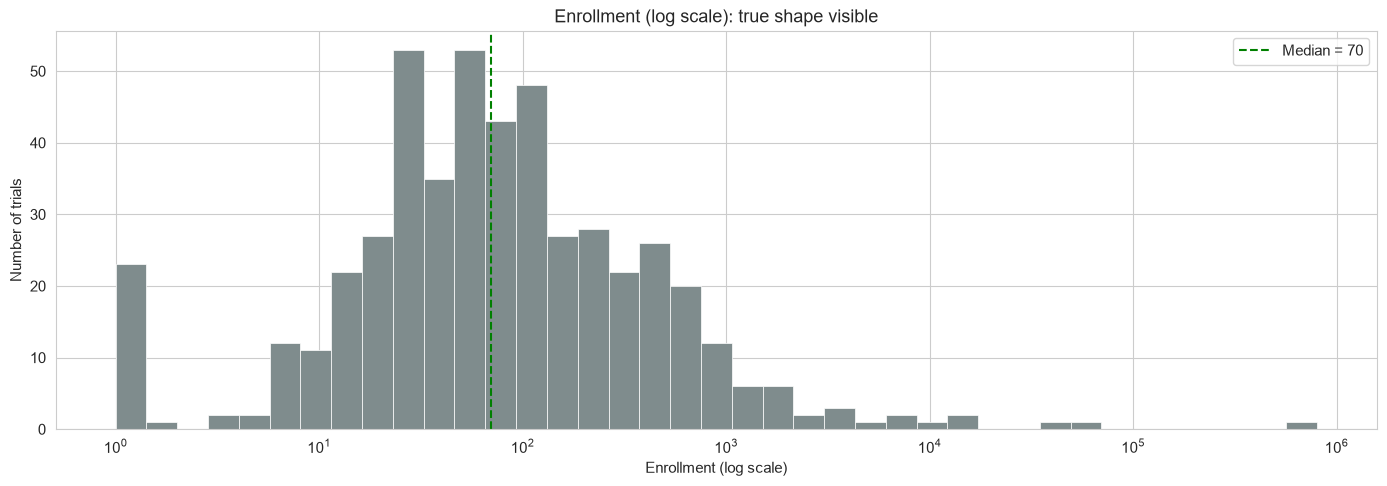

In [9]:
df = pd.read_sql("SELECT enrollment FROM studies WHERE enrollment IS NOT NULL", conn)

fig, ax2 = plt.subplots(figsize=(14, 5))

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# # Left: raw scale — shows the extreme skew (this was already correct)
# ax1.hist(df['enrollment'], bins=50, color='#7f8c8d')
# ax1.axvline(df['enrollment'].mean(), color='red', linestyle='--',
#             label=f"Mean = {df['enrollment'].mean():,.0f}")
# ax1.axvline(df['enrollment'].median(), color='green', linestyle='--',
#             label=f"Median = {df['enrollment'].median():,.0f}")
# ax1.set_title('Enrollment (raw scale): extreme right-skew')
# ax1.set_xlabel('Enrollment')
# ax1.set_ylabel('Number of trials')
# ax1.legend()

# Right: log scale with LOG-SPACED bins (the fix)
positive = df['enrollment'].clip(lower=1)          # avoid log(0)
log_bins = np.logspace(0, np.log10(positive.max()), 40)   # bins spaced evenly in log space

ax2.hist(positive, bins=log_bins, color='#7f8c8d', edgecolor='white', linewidth=0.5)
ax2.set_xscale('log')
ax2.axvline(df['enrollment'].median(), color='green', linestyle='--',
            label=f"Median = {df['enrollment'].median():,.0f}")
ax2.set_title('Enrollment (log scale): true shape visible')
ax2.set_xlabel('Enrollment (log scale)')
ax2.set_ylabel('Number of trials')
ax2.legend()

plt.tight_layout()
plt.show()

In [5]:
df = pd.read_sql("SELECT enrollment FROM studies WHERE enrollment IS NOT NULL", conn)

# How many trials are under 16,000 (the first bin's width)?
under_16k = (df['enrollment'] < 16000).sum()
print(f"Trials under 16,000: {under_16k} of {len(df)} ({100*under_16k/len(df):.1f}%)")

# How many are above 100,000?
over_100k = (df['enrollment'] > 100000).sum()
print(f"Trials over 100,000: {over_100k}")

Trials under 16,000: 489 of 493 (99.2%)
Trials over 100,000: 1


In [2]:
query = """
WITH status_counts AS (
    SELECT phase,
           COUNT(*) AS total,
           SUM(CASE WHEN status = 'COMPLETED' THEN 1 ELSE 0 END) AS completed,
           SUM(CASE WHEN status = 'UNKNOWN' THEN 1 ELSE 0 END) AS unknown_status
    FROM studies
    WHERE study_type = 'INTERVENTIONAL' AND phase IS NOT NULL AND phase != 'NA'
    GROUP BY phase
)
SELECT phase,
       ROUND(100.0 * completed / total, 1) AS naive_rate,
       ROUND(100.0 * completed / NULLIF(total - unknown_status, 0), 1) AS adjusted_rate
FROM status_counts
WHERE phase != 'EARLY_PHASE1'   -- exclude n=3, too small
ORDER BY phase
"""
df = pd.read_sql(query, conn)

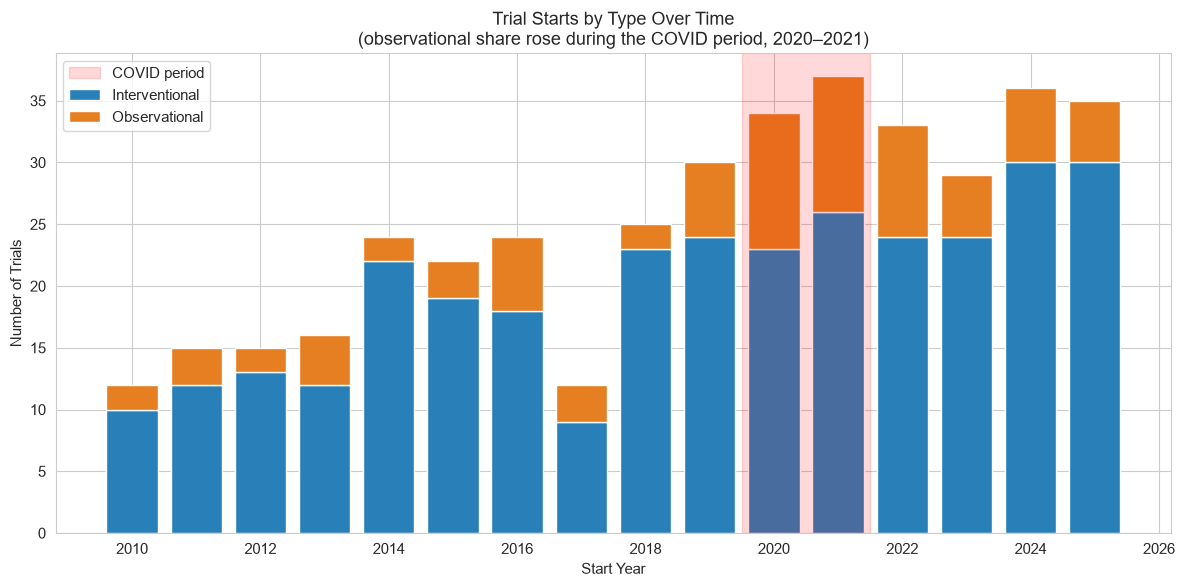

 year  interventional  observational  obs_pct
 2010              10              2     16.7
 2011              12              3     20.0
 2012              13              2     13.3
 2013              12              4     25.0
 2014              22              2      8.3
 2015              19              3     13.6
 2016              18              6     25.0
 2017               9              3     25.0
 2018              23              2      8.0
 2019              24              6     20.0
 2020              23             11     32.4
 2021              26             11     29.7
 2022              24              9     27.3
 2023              24              5     17.2
 2024              30              6     16.7
 2025              30              5     14.3


In [10]:
query = """
SELECT
    CAST(SUBSTR(start_date, 1, 4) AS INTEGER) AS year,
    SUM(CASE WHEN study_type = 'INTERVENTIONAL' THEN 1 ELSE 0 END) AS interventional,
    SUM(CASE WHEN study_type = 'OBSERVATIONAL'  THEN 1 ELSE 0 END) AS observational
FROM studies
WHERE start_date IS NOT NULL
  AND CAST(SUBSTR(start_date, 1, 4) AS INTEGER) BETWEEN 2010 AND 2025
GROUP BY year
ORDER BY year
"""
df = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df['year'], df['interventional'], label='Interventional', color='#2980b9')
ax.bar(df['year'], df['observational'], bottom=df['interventional'],
       label='Observational', color='#e67e22')

# Highlight the COVID window
ax.axvspan(2019.5, 2021.5, alpha=0.15, color='red', label='COVID period')

ax.set_xlabel('Start Year')
ax.set_ylabel('Number of Trials')
ax.set_title('Trial Starts by Type Over Time\n(observational share rose during the COVID period, 2020–2021)')
ax.legend()
plt.tight_layout()
plt.show()

# Print the observational share to support the visual
df['obs_pct'] = (100 * df['observational'] / (df['interventional'] + df['observational'])).round(1)
print(df[['year', 'interventional', 'observational', 'obs_pct']].to_string(index=False))

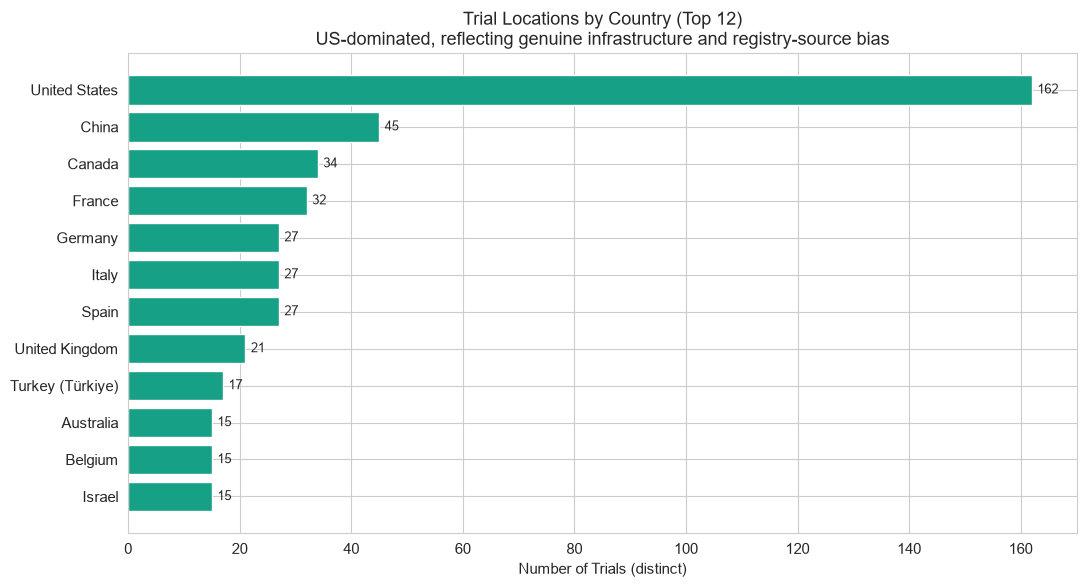

In [11]:
query = """
SELECT country, COUNT(DISTINCT study_id) AS trial_count
FROM locations
WHERE country IS NOT NULL
GROUP BY country
ORDER BY trial_count DESC
LIMIT 12
"""
df = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(df['country'], df['trial_count'], color='#16a085')
ax.invert_yaxis()   # largest at top
ax.set_xlabel('Number of Trials (distinct)')
ax.set_title('Trial Locations by Country (Top 12)\nUS-dominated, reflecting genuine infrastructure and registry-source bias')

for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

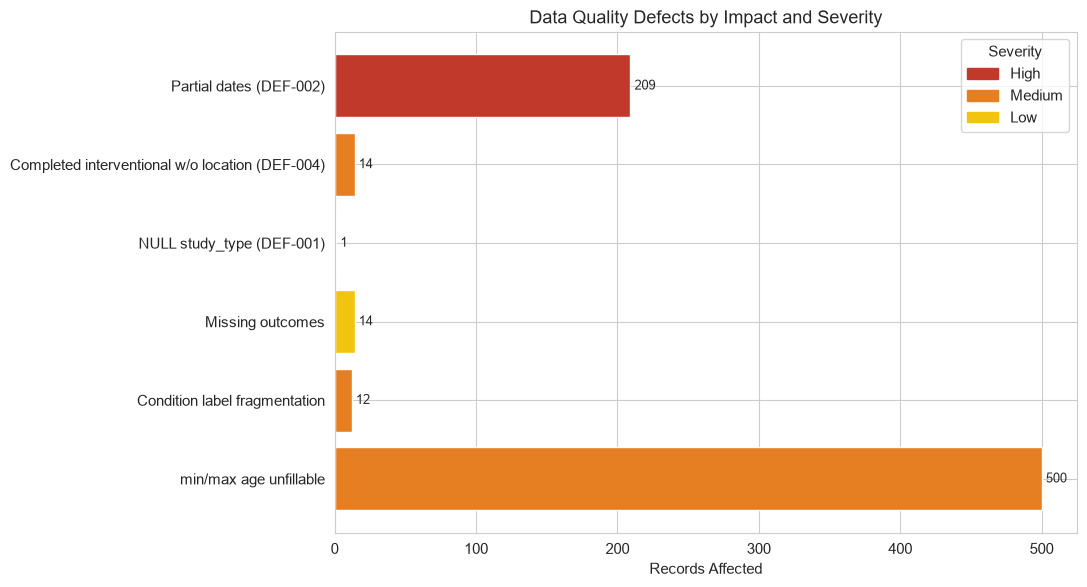

In [12]:
# Summary of your test suite results — adjust counts to match YOUR final defect log
defects = pd.DataFrame({
    'defect': [
        'Partial dates (DEF-002)',
        'Completed interventional w/o location (DEF-004)',
        'NULL study_type (DEF-001)',
        'Missing outcomes',
        'Condition label fragmentation',
        'min/max age unfillable'
    ],
    'affected': [209, 14, 1, 14, 12, 500],
    'severity': ['High', 'Medium', 'Low', 'Low', 'Medium', 'Medium']
})

severity_colors = {'High': '#c0392b', 'Medium': '#e67e22', 'Low': '#f1c40f'}
colors = [severity_colors[s] for s in defects['severity']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(defects['defect'], defects['affected'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Records Affected')
ax.set_title('Data Quality Defects by Impact and Severity')

# Legend for severity
from matplotlib.patches import Patch
legend = [Patch(color=c, label=s) for s, c in severity_colors.items()]
ax.legend(handles=legend, title='Severity')

for bar in bars:
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

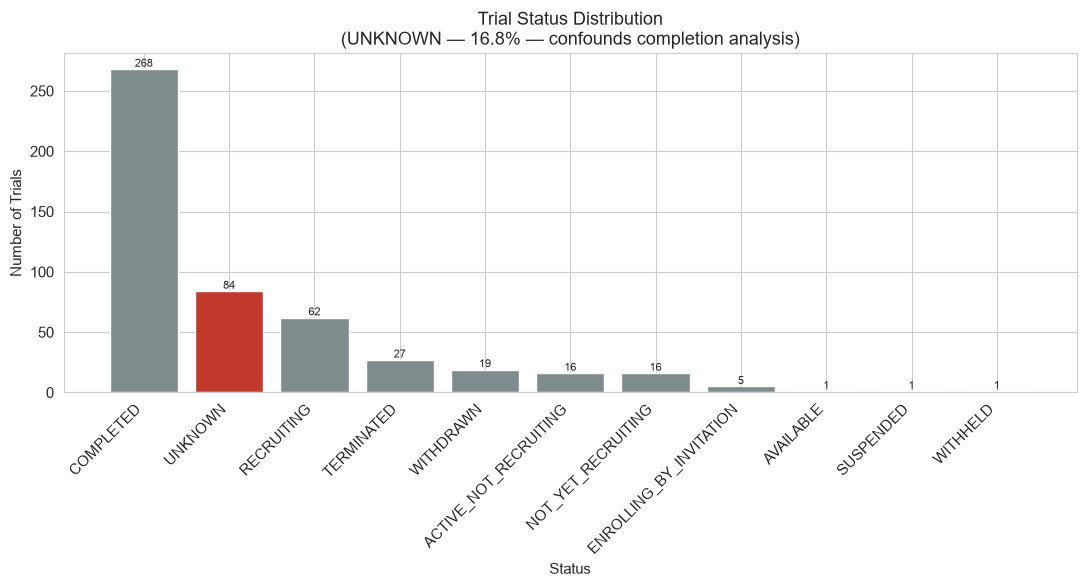

In [13]:
query = """
SELECT status, COUNT(*) AS count
FROM studies
GROUP BY status
ORDER BY count DESC
"""
df = pd.read_sql(query, conn)

# Highlight UNKNOWN (the confounder) in red, others neutral
colors = ['#c0392b' if s == 'UNKNOWN' else '#7f8c8d' for s in df['status']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(df['status'], df['count'], color=colors)
ax.set_xlabel('Status')
ax.set_ylabel('Number of Trials')
ax.set_title('Trial Status Distribution\n(UNKNOWN — 16.8% — confounds completion analysis)')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{int(bar.get_height())}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()